# 03. Regresión logística y auditoría inicial de equidad

Se comparan dos modelos de regresión logística: uno excluye los atributos sensibles y otro los incorpora. El análisis combina métricas predictivas, matrices de confusión, coeficientes y medidas de equidad para sexo, raza y etnia.

**Entrada:** `data/processed/df_lasso2.csv`.

**Resultado:** comparación del rendimiento y de las disparidades observadas entre ambos enfoques.


## 1. Dependencias


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as smdime 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report


## 2. Carga y revisión del conjunto reducido


In [3]:
df_lasso1=pd.read_csv("data/processed/df_lasso2.csv")


In [4]:
df_lasso1.columns


Index(['ratio_deuda_ingresos', 'importe_prestamo', 'sistema_evaluacion_1',
       'ingreso_mediano_area', 'finalidad_prestamo', 'ingresos',
       'ingreso_relativo_zona', 'valor_vivienda', 'ratio_prestamo_valor',
       'codigo_estado', 'sexo', 'raza', 'etnia', 'target'],
      dtype='str')

## 3. Definición de variables y grupos sensibles


In [5]:
target_col = 'target'
sensitive_cols = ['sexo', 'raza', 'etnia']


In [6]:
# patrones a eliminar porque son duplicados o variantes conflictivas
drop_patterns = [
    'sexo_solicitante',
    'sexo_co_solicitante',
    'sexo_observado',
    'raza_solicitante',
    'raza_co_solicitante',
    'etnia_solicitante',
    'etnia_co_solicitante'
]

cols_to_drop = []

for col in df_lasso1.columns:
    for pat in drop_patterns:
        if pat.lower() in col.lower():
            cols_to_drop.append(col)

cols_to_drop = list(set(cols_to_drop))

print("Columnas eliminadas por duplicación/conflicto:")
print(cols_to_drop)


Columnas eliminadas por duplicación/conflicto:
[]


In [7]:
df_lasso1.shape


(2743872, 14)

In [8]:
# quitar nombres duplicados
df_lasso1 = df_lasso1.loc[:, ~df_lasso1.columns.duplicated()].copy()

# quitar columnas totalmente vacías
empty_cols = df_lasso1.columns[df_lasso1.isna().all()].tolist()
df_lasso1 = df_lasso1.drop(columns=empty_cols, errors='ignore')

print("Columnas totalmente vacías eliminadas:")
print(empty_cols)


Columnas totalmente vacías eliminadas:
[]


In [9]:
for c in sensitive_cols:
    if c not in df_lasso1.columns:
        print(f"WARNING: la columna sensible '{c}' no está en el dataframe")


In [10]:
# quitar target y columnas conflictivas
candidate_features = [c for c in df_lasso1.columns if c != target_col and c not in cols_to_drop]

# modelo base: sin sensibles
base_features = [c for c in candidate_features if c not in sensitive_cols]

# modelo con sensibles: mismas + sensibles
sensitive_features = [c for c in candidate_features if c in base_features or c in sensitive_cols]

print("Número de features base:", len(base_features))
print("Número de features con sensibles:", len(sensitive_features))


Número de features base: 10
Número de features con sensibles: 13


In [11]:
X_base = df_lasso1[base_features].copy()
X_sensitive = df_lasso1[sensitive_features].copy()
y = df_lasso1[target_col].copy()


## 4. Preprocesamiento y funciones de evaluación


In [12]:
def force_column_types(X, categorical_manual=None):
    X = X.copy()

    if categorical_manual is None:
        categorical_manual = []

    # forzar algunas columnas a string aunque estén como int/float
    for col in categorical_manual:
        if col in X.columns:
            X[col] = X[col].astype('string')

    # detectar columnas categóricas ya tipo object/category/string
    obj_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    # unificar todas las categóricas a string
    all_cat_cols = list(set(obj_cols + [c for c in categorical_manual if c in X.columns]))
    for col in all_cat_cols:
        X[col] = X[col].astype('string')

    return X


In [13]:
def build_preprocessor(X):
    X = X.copy()

    categorical_manual = [
        'preaprobacion',
        'tipo_prestamo',
        'finalidad_prestamo',
        'prioridad_hipoteca',
        'hipoteca_inversa',
        'linea_credito_abierta',
        'finalidad_comercial',
        'estado_hoepa',
        'pago_global',
        'metodo_construccion',
        'tipo_ocupacion',
        'sistema_evaluacion_1',
        'motivo_denegacion',
        'spread_faltante',
        'sexo',
        'raza',
        'etnia'
    ]

    # Forzar tipos coherentes
    X = force_column_types(X, categorical_manual=categorical_manual)

    categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    numeric_features = [c for c in X.columns if c not in categorical_features]

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features


In [14]:
def train_evaluate_logistic(X, y, model_name="Modelo"):
    X = X.copy()

    categorical_manual = [
        'preaprobacion',
        'tipo_prestamo',
        'finalidad_prestamo',
        'prioridad_hipoteca',
        'hipoteca_inversa',
        'linea_credito_abierta',
        'finalidad_comercial',
        'estado_hoepa',
        'pago_global',
        'metodo_construccion',
        'tipo_ocupacion',
        'sistema_evaluacion_1',
        'motivo_denegacion',
        'spread_faltante',
        'sexo',
        'raza',
        'etnia'
    ]

    # Forzar tipos antes del split
    X = force_column_types(X, categorical_manual=categorical_manual)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocessor, num_cols, cat_cols = build_preprocessor(X)

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=2000,
            solver='lbfgs',
            tol=1e-4,
            n_jobs=-1
        ))
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return clf, X_train, X_test, y_train, y_test, y_pred, y_prob


In [15]:
def find_mixed_type_columns(df):
    mixed_cols = []
    for col in df.columns:
        non_null = df[col].dropna()
        types_found = set(type(x).__name__ for x in non_null)
        if len(types_found) > 1:
            mixed_cols.append((col, types_found))
    return mixed_cols

print("Columnas con tipos mezclados en X_base:")
for col, types_found in find_mixed_type_columns(X_base):
    print(col, types_found)

print("\nColumnas con tipos mezclados en X_sensitive:")
for col, types_found in find_mixed_type_columns(X_sensitive):
    print(col, types_found)


Columnas con tipos mezclados en X_base:

Columnas con tipos mezclados en X_sensitive:


## 5. Entrenamiento y comparación de modelos


In [16]:
model_base, X_train_b, X_test_b, y_train_b, y_test_b, y_pred_b, y_prob_b = train_evaluate_logistic(
    X_base, y, model_name="Modelo base SIN variables sensibles"
)


c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



===== Modelo base SIN variables sensibles =====
Accuracy: 0.7920696095849847
AUC: 0.8701843103184366
Matriz de confusión:
[[140119  58156]
 [ 55951 294549]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71    198275
           1       0.84      0.84      0.84    350500

    accuracy                           0.79    548775
   macro avg       0.77      0.77      0.77    548775
weighted avg       0.79      0.79      0.79    548775



In [17]:
model_sensitive, X_train_s, X_test_s, y_train_s, y_test_s, y_pred_s, y_prob_s = train_evaluate_logistic(
    X_sensitive, y, model_name="Modelo CON variables sensibles"
)


c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



===== Modelo CON variables sensibles =====
Accuracy: 0.7961040499293882
AUC: 0.8727344155538379
Matriz de confusión:
[[140369  57906]
 [ 53987 296513]]

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.72    198275
           1       0.84      0.85      0.84    350500

    accuracy                           0.80    548775
   macro avg       0.78      0.78      0.78    548775
weighted avg       0.80      0.80      0.80    548775



In [18]:
print("\n===== COMPARACIÓN FINAL =====")
print("AUC base:      ", roc_auc_score(y_test_b, y_prob_b))
print("AUC sensible:  ", roc_auc_score(y_test_s, y_prob_s))
print("Delta AUC:     ", roc_auc_score(y_test_s, y_prob_s) - roc_auc_score(y_test_b, y_prob_b))

print("Accuracy base:     ", accuracy_score(y_test_b, y_pred_b))
print("Accuracy sensible: ", accuracy_score(y_test_s, y_pred_s))
print("Delta Accuracy:    ", accuracy_score(y_test_s, y_pred_s) - accuracy_score(y_test_b, y_pred_b))



===== COMPARACIÓN FINAL =====
AUC base:       0.8701843103184366
AUC sensible:   0.8727344155538379
Delta AUC:      0.0025501052354013343
Accuracy base:      0.7920696095849847
Accuracy sensible:  0.7961040499293882
Delta Accuracy:     0.004034440344403478


## 6. Interpretación de coeficientes


In [19]:
def get_feature_names_from_pipeline(fitted_pipeline, X):
    X = X.copy()

    categorical_manual = [
        'preaprobacion',
        'tipo_prestamo',
        'finalidad_prestamo',
        'prioridad_hipoteca',
        'hipoteca_inversa',
        'linea_credito_abierta',
        'finalidad_comercial',
        'estado_hoepa',
        'pago_global',
        'metodo_construccion',
        'tipo_ocupacion',
        'sistema_evaluacion_1',
        'motivo_denegacion',
        'spread_faltante',
        'sexo',
        'raza',
        'etnia'
    ]

    X = force_column_types(X, categorical_manual=categorical_manual)

    preprocessor = fitted_pipeline.named_steps['preprocessor']

    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()

    feature_names = numeric_features + cat_feature_names
    return feature_names


feature_names_sensitive = get_feature_names_from_pipeline(model_sensitive, X_sensitive)

coef_sensitive = model_sensitive.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'variable': feature_names_sensitive,
    'coeficiente': coef_sensitive
})

coef_df['odds_ratio'] = np.exp(coef_df['coeficiente'])
coef_df['abs_coef'] = coef_df['coeficiente'].abs()

coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("\n===== TOP COEFICIENTES MODELO CON SENSIBLES =====")
print(coef_df.head(30))


sens_keywords = ['sexo', 'raza', 'etnia']

coef_sens = coef_df[
    coef_df['variable'].str.contains('|'.join(sens_keywords), case=False, na=False)
].copy()

print("\n===== COEFICIENTES DE VARIABLES SENSIBLES =====")
print(coef_sens.sort_values('abs_coef', ascending=False))



===== TOP COEFICIENTES MODELO CON SENSIBLES =====
                                          variable  coeficiente  odds_ratio  \
12                          sistema_evaluacion_1_7    -2.539401    0.078914   
10                          sistema_evaluacion_1_5    -2.172389    0.113905   
11                          sistema_evaluacion_1_6    -2.015342    0.133275   
8                           sistema_evaluacion_1_3    -1.582719    0.205416   
15                           finalidad_prestamo_32    -0.934531    0.392770   
13                            finalidad_prestamo_2    -0.902614    0.405508   
16                            finalidad_prestamo_4    -0.803971    0.447548   
7                           sistema_evaluacion_1_2     0.764504    2.147929   
0                             ratio_deuda_ingresos    -0.741587    0.476357   
78                    etnia_Not Hispanic or Latino     0.650473    1.916448   
74                                      raza_White     0.634831    1.886704   
3

In [20]:
sens_keywords = ['sexo', 'raza', 'etnia']

coef_sens = coef_df[
    coef_df['variable'].str.contains('|'.join(sens_keywords), case=False, na=False)
].copy()

print("\n===== COEFICIENTES DE VARIABLES SENSIBLES =====")
print(coef_sens.sort_values('abs_coef', ascending=False))



===== COEFICIENTES DE VARIABLES SENSIBLES =====
                                          variable  coeficiente  odds_ratio  \
78                    etnia_Not Hispanic or Latino     0.650473    1.916448   
74                                      raza_White     0.634831    1.886704   
71                                      raza_Asian     0.397658    1.488336   
73  raza_Native Hawaiian or Other Pacific Islander     0.280529    1.323830   
76                        etnia_Hispanic or Latino     0.233091    1.262497   
75                       etnia_Free Form Text Only    -0.180561    0.834802   
77                                     etnia_Joint     0.158777    1.172076   
72                  raza_Black or African American     0.155993    1.168818   
70           raza_American Indian or Alaska Native     0.126369    1.134700   
69                                      sexo_mujer     0.087565    1.091513   

    abs_coef  
78  0.650473  
74  0.634831  
71  0.397658  
73  0.280529  
76  0.

## 7. Matrices de confusión


In [21]:
md = confusion_matrix(y_test_s, y_pred_s)
md_pct = md/ md.sum()


In [22]:
dm= confusion_matrix(y_test_b, y_pred_b)
dm_pct = dm/ dm.sum()


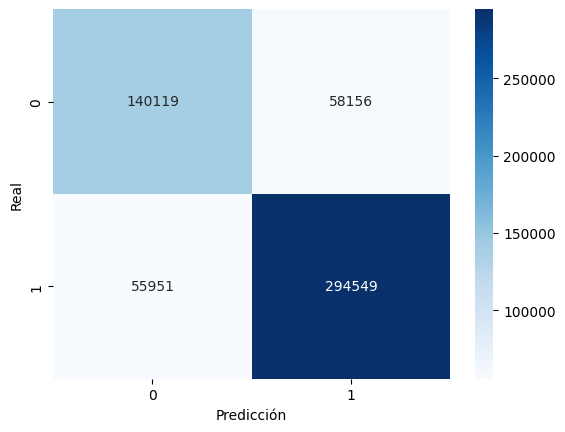

In [23]:
sns.heatmap(dm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("")

plt.show()


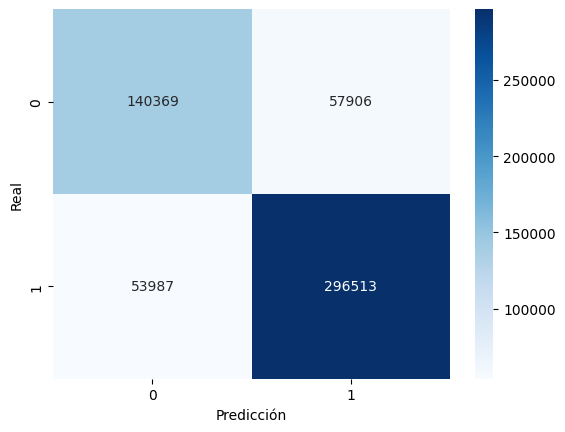

In [24]:
sns.heatmap(md, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("")

plt.show()


## 8. Evaluación complementaria


In [25]:
cm = confusion_matrix(y_test_s, y_pred_s)
cm_pct = cm / cm.sum()

print("Matriz de confusión absoluta:")
print(cm)

print("Matriz de confusión en proporciones:")
print(cm_pct)


Matriz de confusión absoluta:
[[140369  57906]
 [ 53987 296513]]
Matriz de confusión en proporciones:
[[0.25578607 0.10551866]
 [0.09837729 0.54031798]]


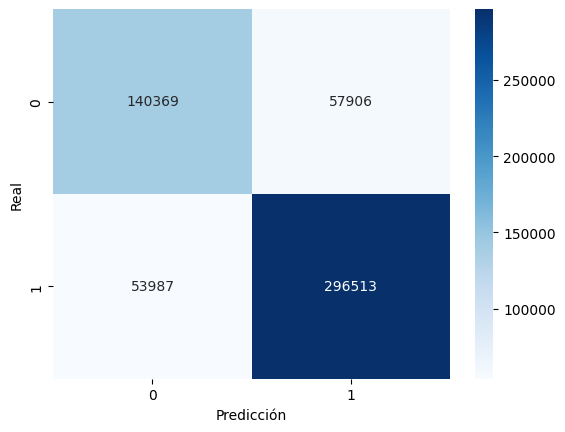

In [26]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("")

plt.show()


La eliminación de variables sensibles no implica necesariamente la eliminación del sesgo en el modelo.

En particular, existen variables proxy, es decir, variables no sensibles que están correlacionadas con atributos demográficos como raza, sexo o etnia. Estas variables permiten al modelo reconstruir indirectamente dicha información.

En este caso, el hecho de que el rendimiento del modelo se mantenga inalterado tras eliminar las variables sensibles sugiere la presencia de este tipo de relaciones indirectas en los datos.

Por tanto, la equidad del modelo no puede garantizarse únicamente mediante la eliminación de atributos sensibles, siendo necesario aplicar técnicas específicas de fairness.


## 9. Métricas de equidad de los dos modelos


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

def safe_div(a, b):
    return np.nan if b == 0 else a / b

def group_binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    positive_rate = np.mean(y_pred == 1)
    fpr = safe_div(fp, fp + tn)
    tpr = safe_div(tp, tp + fn)
    fnr = safe_div(fn, fn + tp)
    tnr = safe_div(tn, tn + fp)

    return {
        'n': len(y_true),
        'accuracy': acc,
        'precision': prec,
        'recall_tpr': tpr,
        'f1': f1,
        'positive_rate': positive_rate,
        'fpr': fpr,
        'fnr': fnr,
        'tnr': tnr
    }

def fairness_between_groups(df_group_metrics, ref_group=None):
    dfg = df_group_metrics.copy()

    if ref_group is None:
        ref_group = dfg.sort_values('n', ascending=False)['group'].iloc[0]

    ref = dfg[dfg['group'] == ref_group].iloc[0]

    rows = []
    for _, row in dfg.iterrows():
        dp_diff = row['positive_rate'] - ref['positive_rate']
        di_ratio = safe_div(row['positive_rate'], ref['positive_rate'])
        eo_diff = row['recall_tpr'] - ref['recall_tpr']
        avg_odds_diff = 0.5 * (
            (row['recall_tpr'] - ref['recall_tpr']) +
            (row['fpr'] - ref['fpr'])
        )

        rows.append({
            'group': row['group'],
            'reference_group': ref_group,
            'n': row['n'],
            'accuracy': row['accuracy'],
            'precision': row['precision'],
            'recall_tpr': row['recall_tpr'],
            'f1': row['f1'],
            'positive_rate': row['positive_rate'],
            'fpr': row['fpr'],
            'demographic_parity_diff': dp_diff,
            'disparate_impact_ratio': di_ratio,
            'equal_opportunity_diff': eo_diff,
            'average_odds_diff': avg_odds_diff
        })

    return pd.DataFrame(rows)

def evaluate_fairness_on_test(model, X_test, y_test, sensitive_series, attribute_name, threshold=0.5, ref_group=None):
    """
    Calcula métricas de fairness EXCLUSIVAMENTE sobre el conjunto de test.
    El modelo ya debe estar entrenado previamente sobre train.
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tmp = pd.DataFrame({
        'y_true': y_test.values if hasattr(y_test, 'values') else y_test,
        'y_pred': y_pred,
        'group': sensitive_series.values if hasattr(sensitive_series, 'values') else sensitive_series
    }).copy()

    tmp['group'] = tmp['group'].astype(str).fillna('MISSING')

    group_rows = []
    for grp, sub in tmp.groupby('group'):
        metrics = group_binary_metrics(sub['y_true'], sub['y_pred'])
        metrics['group'] = grp
        group_rows.append(metrics)

    df_group = pd.DataFrame(group_rows)
    df_fair = fairness_between_groups(df_group, ref_group=ref_group)
    df_fair.insert(0, 'attribute', attribute_name)

    return df_fair.sort_values('n', ascending=False)


In [28]:
# Recuperamos exclusivamente las variables sensibles correspondientes a los conjuntos de test.
# Esto garantiza que las métricas de fairness se calculan sobre observaciones no vistas
# durante el entrenamiento del modelo.

sens_test_b = df_lasso1.loc[X_test_b.index, ['sexo', 'raza', 'etnia']].copy()
sens_test_s = df_lasso1.loc[X_test_s.index, ['sexo', 'raza', 'etnia']].copy()


In [29]:
# Fairness del modelo base evaluada EXCLUSIVAMENTE sobre el conjunto de test

fair_base_sexo = evaluate_fairness_on_test(
    model=model_base,
    X_test=X_test_b,
    y_test=y_test_b,
    sensitive_series=sens_test_b['sexo'],
    attribute_name='sexo'
)

fair_base_raza = evaluate_fairness_on_test(
    model=model_base,
    X_test=X_test_b,
    y_test=y_test_b,
    sensitive_series=sens_test_b['raza'],
    attribute_name='raza'
)

fair_base_etnia = evaluate_fairness_on_test(
    model=model_base,
    X_test=X_test_b,
    y_test=y_test_b,
    sensitive_series=sens_test_b['etnia'],
    attribute_name='etnia'
)

fair_base = pd.concat(
    [fair_base_sexo, fair_base_raza, fair_base_etnia],
    ignore_index=True
)

fair_base['model'] = 'base_sin_sensibles'
fair_base


,attribute,group,reference_group,n,accuracy,precision,recall_tpr,f1,positive_rate,fpr,demographic_parity_diff,disparate_impact_ratio,equal_opportunity_diff,average_odds_diff,model
0,sexo,hombre,hombre,328806,0.789630,0.828956,0.851303,0.839981,0.666071,0.324197,0.000000,1.000000,0.000000,0.000000,base_sin_sensibles
1,sexo,mujer,hombre,219969,0.795717,0.845202,0.823376,0.834147,0.607799,0.250169,-0.058271,0.912515,-0.027926,-0.050977,base_sin_sensibles
2,raza,White,White,406098,0.790240,0.843544,0.836664,0.840090,0.653182,0.299298,0.000000,1.000000,0.000000,0.000000,base_sin_sensibles
3,raza,Asian,White,72632,0.822695,0.844045,0.906513,0.874165,0.729651,0.354904,0.076469,1.117071,0.069849,0.062727,base_sin_sensibles
4,raza,Black or African American,White,59910,0.770639,0.762644,0.773611,0.768088,0.498030,0.232227,-0.155152,0.762468,-0.063053,-0.065062,base_sin_sensibles
5,raza,American Indian or Alaska Native,White,5599,0.774781,0.726861,0.781478,0.753181,0.472763,0.230475,-0.180419,0.723784,-0.055186,-0.062005,base_sin_sensibles
6,raza,Native Hawaiian or Other Pacific Islander,White,2658,0.782167,0.715953,0.719453,0.717699,0.386757,0.178593,-0.266425,0.592112,-0.117212,-0.118958,base_sin_sensibles
7,raza,2 or more minority races,White,1878,0.752396,0.688629,0.790244,0.735945,0.501065,0.276938,-0.152117,0.767114,-0.046420,-0.034391,base_sin_sensibles
8,etnia,Not Hispanic or Latino,Not Hispanic or Latino,459927,0.792041,0.842963,0.843483,0.843223,0.663436,0.309176,0.000000,1.000000,0.000000,0.000000,base_sin_sensibles
9,etnia,Hispanic or Latino,Not Hispanic or Latino,69965,0.797956,0.801168,0.816615,0.808818,0.533452,0.222532,-0.129983,0.804076,-0.026868,-0.056756,base_sin_sensibles


1. demographic_parity_diff - tasa de prediccion positiva entre un grupo y el de referencia 
- 0 → ambos grupos reciben predicción positiva en la misma proporción
- negativo → ese grupo recibe menos predicciones positivas que el de referencia
- positivo → ese grupo recibe más predicciones positivas que el de referencia

2. disparate_impact_ratio - La razón entre la tasa de predicción positiva del grupo y la del grupo de referencia. (tabla p-valroes)
- 1 → igualdad perfecta
- < 1 → ese grupo recibe menos predicciones positivas que la referencia
- > 1 → ese grupo recibe más predicciones positivas que la referencia

3. equal_opportunity_diff - a diferencia en el recall / true positive rate (TPR) entre grupos $\text{EO diff} = TPR(grupo) - TPR(referencia)$

- 0 → el modelo detecta los positivos reales igual de bien en ambos grupos
- negativo → detecta peor los positivos reales en ese grupo
- positivo → detecta mejor los positivos reales en ese grupo

4. average_odds_diff - Resume la diferencia conjunta en:

TPR (recall)
FPR (false positive rate) $\text{Average Odds Diff} = \frac{(TPR_g - TPR_r) + (FPR_g - FPR_r)}{2}$

- 0 → comportamiento muy similar entre grupo y referencia
- negativo → en promedio ese grupo sale peor parado que la referencia
- positivo → en promedio sale mejor o recibe más positivos/falsos positivos que la referencia


In [30]:
# Fairness del modelo con variables sensibles evaluada EXCLUSIVAMENTE sobre el conjunto de test

fair_sensitive_sexo = evaluate_fairness_on_test(
    model=model_sensitive,
    X_test=X_test_s,
    y_test=y_test_s,
    sensitive_series=sens_test_s['sexo'],
    attribute_name='sexo'
)

fair_sensitive_raza = evaluate_fairness_on_test(
    model=model_sensitive,
    X_test=X_test_s,
    y_test=y_test_s,
    sensitive_series=sens_test_s['raza'],
    attribute_name='raza'
)

fair_sensitive_etnia = evaluate_fairness_on_test(
    model=model_sensitive,
    X_test=X_test_s,
    y_test=y_test_s,
    sensitive_series=sens_test_s['etnia'],
    attribute_name='etnia'
)

fair_sensitive = pd.concat(
    [fair_sensitive_sexo, fair_sensitive_raza, fair_sensitive_etnia],
    ignore_index=True
)

fair_sensitive['model'] = 'con_sensibles'
fair_sensitive


,attribute,group,reference_group,n,accuracy,precision,recall_tpr,f1,positive_rate,fpr,demographic_parity_diff,disparate_impact_ratio,equal_opportunity_diff,average_odds_diff,model
0,sexo,hombre,hombre,328806,0.793179,0.832639,0.852466,0.842436,0.664030,0.316244,0.000000,1.000000,0.000000,0.000000,con_sensibles
1,sexo,mujer,hombre,219969,0.800476,0.842999,0.835880,0.839424,0.618642,0.258256,-0.045388,0.931647,-0.016586,-0.037287,con_sensibles
2,raza,White,White,406098,0.794109,0.837915,0.852208,0.845001,0.669787,0.317948,0.000000,1.000000,0.000000,0.000000,con_sensibles
3,raza,Asian,White,72632,0.823136,0.851551,0.895833,0.873131,0.714699,0.330900,0.044912,1.067054,0.043625,0.028289,con_sensibles
4,raza,Black or African American,White,59910,0.776999,0.800862,0.726423,0.761828,0.445335,0.174220,-0.224452,0.664890,-0.125785,-0.134757,con_sensibles
5,raza,American Indian or Alaska Native,White,5599,0.797642,0.802458,0.716084,0.756815,0.392391,0.138349,-0.277395,0.585846,-0.136124,-0.157862,con_sensibles
6,raza,Native Hawaiian or Other Pacific Islander,White,2658,0.799473,0.781609,0.664712,0.718436,0.327314,0.116208,-0.342473,0.488684,-0.187497,-0.194618,con_sensibles
7,raza,2 or more minority races,White,1878,0.782215,0.769332,0.715854,0.741630,0.406283,0.166352,-0.263503,0.606586,-0.136355,-0.143976,con_sensibles
8,etnia,Not Hispanic or Latino,Not Hispanic or Latino,459927,0.795089,0.838398,0.855928,0.847072,0.676890,0.324616,0.000000,1.000000,0.000000,0.000000,con_sensibles
9,etnia,Hispanic or Latino,Not Hispanic or Latino,69965,0.802201,0.828459,0.784499,0.805880,0.495591,0.178362,-0.181299,0.732158,-0.071429,-0.108842,con_sensibles


In [31]:
# Unimos los resultados de fairness de ambos modelos.
# Todas las métricas aquí contenidas han sido calculadas únicamente sobre test.

fair_all = pd.concat([fair_base, fair_sensitive], ignore_index=True)

cols_show = [
    'model', 'attribute', 'group', 'reference_group', 'n',
    'accuracy', 'precision', 'recall_tpr', 'f1',
    'positive_rate', 'fpr',
    'demographic_parity_diff',
    'disparate_impact_ratio',
    'equal_opportunity_diff',
    'average_odds_diff'
]

fair_all = fair_all[cols_show].sort_values(
    ['attribute', 'model', 'n'],
    ascending=[True, True, False]
)

fair_all


,model,attribute,group,reference_group,n,accuracy,precision,recall_tpr,f1,positive_rate,fpr,demographic_parity_diff,disparate_impact_ratio,equal_opportunity_diff,average_odds_diff
8,base_sin_sensibles,etnia,Not Hispanic or Latino,Not Hispanic or Latino,459927,0.792041,0.842963,0.843483,0.843223,0.663436,0.309176,0.000000,1.000000,0.000000,0.000000
9,base_sin_sensibles,etnia,Hispanic or Latino,Not Hispanic or Latino,69965,0.797956,0.801168,0.816615,0.808818,0.533452,0.222532,-0.129983,0.804076,-0.026868,-0.056756
10,base_sin_sensibles,etnia,Ethnicity Not Available,Not Hispanic or Latino,13940,0.765136,0.719838,0.830549,0.771241,0.550000,0.294448,-0.113436,0.829018,-0.012933,-0.013831
11,base_sin_sensibles,etnia,Joint,Not Hispanic or Latino,2695,0.788868,0.784768,0.829251,0.806397,0.560297,0.256714,-0.103139,0.844538,-0.014232,-0.033347
12,base_sin_sensibles,etnia,Free Form Text Only,Not Hispanic or Latino,2248,0.785587,0.678472,0.841618,0.751290,0.477313,0.249458,-0.186123,0.719457,-0.001864,-0.030791
21,con_sensibles,etnia,Not Hispanic or Latino,Not Hispanic or Latino,459927,0.795089,0.838398,0.855928,0.847072,0.676890,0.324616,0.000000,1.000000,0.000000,0.000000
22,con_sensibles,etnia,Hispanic or Latino,Not Hispanic or Latino,69965,0.802201,0.828459,0.784499,0.805880,0.495591,0.178362,-0.181299,0.732158,-0.071429,-0.108842
23,con_sensibles,etnia,Ethnicity Not Available,Not Hispanic or Latino,13940,0.791392,0.797769,0.753348,0.774923,0.450143,0.173955,-0.226747,0.665017,-0.102579,-0.126620
24,con_sensibles,etnia,Joint,Not Hispanic or Latino,2695,0.804082,0.836948,0.783065,0.809111,0.496104,0.172196,-0.180786,0.732917,-0.072863,-0.112641
25,con_sensibles,etnia,Free Form Text Only,Not Hispanic or Latino,2248,0.833630,0.801968,0.753757,0.777116,0.361655,0.116414,-0.315235,0.534289,-0.102170,-0.155187


In [32]:
# Resumen de fairness:
# Para cada modelo y atributo sensible, se recoge la máxima brecha absoluta observada
# entre grupos en el conjunto de test.

summary_fairness = fair_all.copy()

summary_fairness['abs_demographic_parity_diff'] = summary_fairness['demographic_parity_diff'].abs()
summary_fairness['abs_equal_opportunity_diff'] = summary_fairness['equal_opportunity_diff'].abs()
summary_fairness['abs_average_odds_diff'] = summary_fairness['average_odds_diff'].abs()
summary_fairness['di_distance_to_1'] = (summary_fairness['disparate_impact_ratio'] - 1).abs()

summary_table = summary_fairness.groupby(['model', 'attribute']).agg({
    'abs_demographic_parity_diff': 'max',
    'di_distance_to_1': 'max',
    'abs_equal_opportunity_diff': 'max',
    'abs_average_odds_diff': 'max'
}).reset_index()

summary_table


,model,attribute,abs_demographic_parity_diff,di_distance_to_1,abs_equal_opportunity_diff,abs_average_odds_diff
0,base_sin_sensibles,etnia,0.186123,0.280543,0.026868,0.056756
1,base_sin_sensibles,raza,0.266425,0.407888,0.117212,0.118958
2,base_sin_sensibles,sexo,0.058271,0.087485,0.027926,0.050977
3,con_sensibles,etnia,0.315235,0.465711,0.102579,0.155187
4,con_sensibles,raza,0.342473,0.511316,0.187497,0.194618
5,con_sensibles,sexo,0.045388,0.068353,0.016586,0.037287


1. abs_demographic_parity_diff- lo que busca es la mayor diferencia en cuanto a la tasa de prediccion positiva respecto al grupo de referencia. 
- ej: dentro de todos los grupos raciales, el grupo más alejado del grupo de referencia tiene una diferencia máxima de 0.273389 en su tasa de predicción positiva.
-text{demographic_parity_diff} = positive\_rate(grupo) - positive\_rate(referencia)
Ahora cogemos el valor absoluto:

|\text{demographic_parity_diff}|

2. di_distance_to_1 - $|DI - 1|$ donde:
$$DI = \frac{positive\_rate(grupo)}{positive\_rate(referencia)}$$

- cuánto se aleja el peor grupo del valor ideal, donde 0 es perfecto

3. abs_equal_opportunity_diff Antes:

\text{equal_opportunity_diff} = TPR(grupo) - TPR(referencia)
Ahora:

|\text{equal_opportunity_diff}|

- Mide la mayor diferencia en recall / true positive rate entre cualquier grupo y el grupo de referencia.

En otras palabras:

cuál es la mayor desigualdad en la capacidad del modelo para detectar positivos reales según el grupo.

Cómo interpretarlo: mas cerca de 0 mejor 


4. abs_average_odds_diff
- Es el valor absoluto de average_odds_diff.

Antes:

\text{average_odds_diff} = \frac{(TPR_g - TPR_r) + (FPR_g - FPR_r)}{2}
Ahora coges el valor absoluto y luego el máximo.

- Qué significa
Resume la mayor discrepancia conjunta entre grupos en:

tasa de verdaderos positivos
tasa de falsos positivos
Cómo interpretarlo :más cerca de 0 = mejor


In [33]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

metrics_dict = {
    "selection_rate": selection_rate,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate
}

y_pred_base = model_base.predict(X_test_b)
y_pred_sensitive = model_sensitive.predict(X_test_s)

mf_base_sexo = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test_b,
    y_pred=y_pred_base,
    sensitive_features=sens_test_b["sexo"]
)

mf_sensitive_sexo = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test_s,
    y_pred=y_pred_sensitive,
    sensitive_features=sens_test_s["sexo"]
)

print("=== MetricFrame | modelo base | sexo ===")
print(mf_base_sexo.by_group)

print("=== MetricFrame | modelo con sensibles | sexo ===")
print(mf_sensitive_sexo.by_group)


=== MetricFrame | modelo base | sexo ===
        selection_rate       tpr       fpr
sexo                                      
hombre        0.666071  0.851303  0.324197
mujer         0.607799  0.823376  0.250169
=== MetricFrame | modelo con sensibles | sexo ===
        selection_rate       tpr       fpr
sexo                                      
hombre        0.664030  0.852466  0.316244
mujer         0.618642  0.835880  0.258256


## 10. Conclusiones


Se compararon las métricas de fairness entre el modelo base sin variables sensibles y el modelo con variables sensibles para los atributos sexo, raza y etnia. Los resultados muestran que ambos modelos presentan un comportamiento muy similar en términos globales. Sin embargo, la inclusión de variables sensibles no mejora de forma consistente la equidad del modelo. En el atributo sexo se observa una mejora marginal en algunas métricas, especialmente en equal opportunity difference. No obstante, para raza y etnia las brechas de fairness aumentan ligeramente en el modelo con sensibles, tanto en demographic parity como en equal opportunity y average odds. En conjunto, los resultados sugieren que incorporar variables sensibles no aporta beneficios claros en fairness y, en algunos grupos, puede incluso incrementar pequeñas disparidades.

Se compararon las métricas de fairness entre el modelo base sin variables sensibles y el modelo con variables sensibles para los atributos sexo, raza y etnia. Los resultados muestran que ambos modelos presentan un comportamiento global muy similar. No obstante, la incorporación de variables sensibles no produce una mejora consistente en equidad. En el atributo sexo se observa una mejora marginal en algunas métricas, pero en raza y etnia aparecen ligeros incrementos en varias brechas, como demographic parity, equal opportunity y average odds. Por tanto, más que evidenciar un sesgo preexistente en el modelo base, los resultados indican que añadir variables sensibles no aporta beneficios claros desde el punto de vista de fairness y puede incluso introducir o acentuar pequeñas disparidades entre grupos.
